[-179.99993 -179.00003 -178.00014 -177.00025 -176.00036 -175.00047
 -174.00058 -173.00069 -172.0008  -171.00091]
[PosixPath('/home/oscar/Projects/ct_reconstruction_project/data/lab_images/acquisition1/Acc1/rescaled0.1/rcropIm01_mean.tif'), PosixPath('/home/oscar/Projects/ct_reconstruction_project/data/lab_images/acquisition1/Acc1/rescaled0.1/rcropIm02_mean.tif'), PosixPath('/home/oscar/Projects/ct_reconstruction_project/data/lab_images/acquisition1/Acc1/rescaled0.1/rcropIm03_mean.tif'), PosixPath('/home/oscar/Projects/ct_reconstruction_project/data/lab_images/acquisition1/Acc1/rescaled0.1/rcropIm04_mean.tif'), PosixPath('/home/oscar/Projects/ct_reconstruction_project/data/lab_images/acquisition1/Acc1/rescaled0.1/rcropIm05_mean.tif'), PosixPath('/home/oscar/Projects/ct_reconstruction_project/data/lab_images/acquisition1/Acc1/rescaled0.1/rcropIm06_mean.tif'), PosixPath('/home/oscar/Projects/ct_reconstruction_project/data/lab_images/acquisition1/Acc1/rescaled0.1/rcropIm07_mean.tif'), Posi

(281, 304)

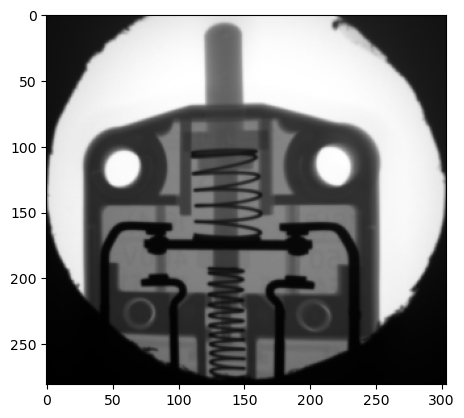

In [11]:
import sys
sys.path.append('..')

import numpy as np
import matplotlib.pyplot as plt
import tifffile as tfff
from pathlib import Path, PureWindowsPath

from recon import *
from imaging.img_utils import crop_acquisition

metafile = Path('/home/oscar/Projects/ct_reconstruction_project/data/lab_images/acquisition1/Acc1/rescaled0.1/metadata.txt')
acq = AcquisitionIndex.from_file(metadata_file=metafile,separator=",")
print(acq._angles[:10])
print(acq._filepaths[:10])

print(f'step info: {acq[1]}')
img = tfff.imread(acq[1].filepath)
plt.imshow(img, cmap='grey')
img.shape

Creating sinogram from row 115 of 360 images...
  Loaded rcropIm01_mean.tif, angle=-179.99993 deg, projection shape: (304,)
  Loaded rcropIm61_mean.tif, angle=-120.00648 deg, projection shape: (304,)
  Loaded rcropIm121_mean.tif, angle=-60.01304 deg, projection shape: (304,)
  Loaded rcropIm181_mean.tif, angle=-0.01959 deg, projection shape: (304,)
  Loaded rcropIm241_mean.tif, angle=59.97385 deg, projection shape: (304,)
  Loaded rcropIm301_mean.tif, angle=119.9673 deg, projection shape: (304,)
Sinogram creation complete. Created 360 projections.


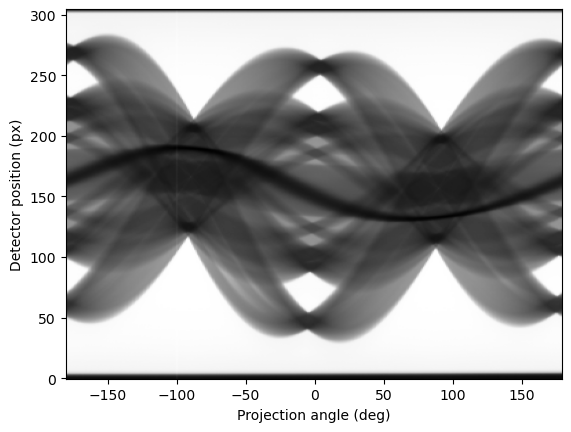

(304, 360)

In [220]:
sino = acq.create_sinogram(row=115)
sino.plot()
sino._data.shape

In [274]:
reco_space = odl.uniform_discr(
    min_pt=[-5, -5], max_pt=[5, 5], shape=[256,256],
    dtype='float32')
angle_partition = odl.uniform_partition(-np.pi, np.pi, 360)
detector_partition = odl.uniform_partition(-10, 10, 304)
geometry = odl.tomo.FanBeamGeometry(angle_partition, detector_partition, src_radius=16.5, det_radius=17, src_to_det_init=(0.15,1.5), det_axis_init=(-0.3,0),)
#src_shift_func=lambda angle: odl.tomo.flying_focal_spot(angle, apart=angle_partition, shifts=[(-0.2, 0.3), (0, 0.2), (4,0)]))

ray_trafo = odl.tomo.RayTransform(reco_space, geometry)
fbp = odl.tomo.fbp_op(ray_trafo, filter_type='Hann', frequency_scaling=0.8)

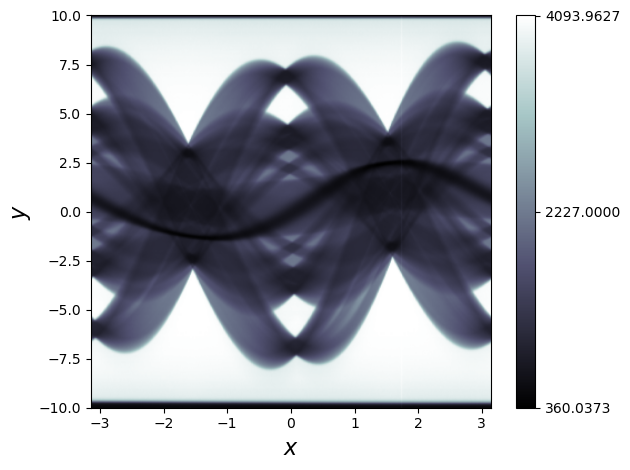

<Figure size 640x480 with 0 Axes>

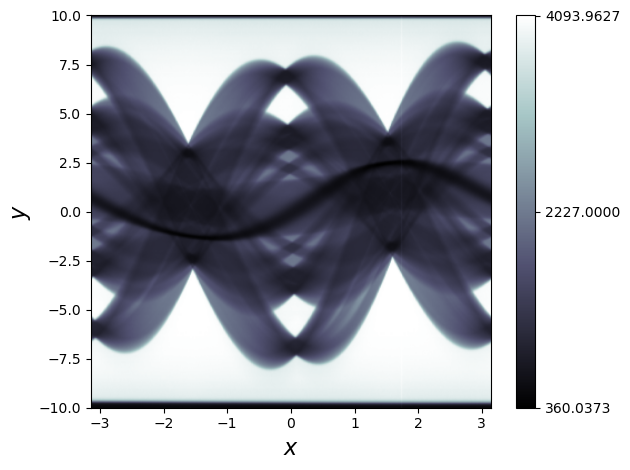

In [221]:
sino_space = odl.uniform_discr(
    min_pt=[-np.pi,-10], max_pt=[np.pi,10], shape=[360,304],
    dtype='float32')

proj_data = sino_space.element(np.flip(sino._data.T))
proj_data.show()

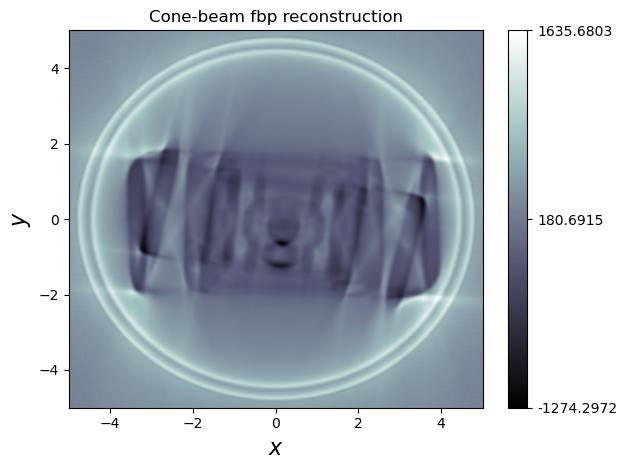

<Figure size 640x480 with 0 Axes>

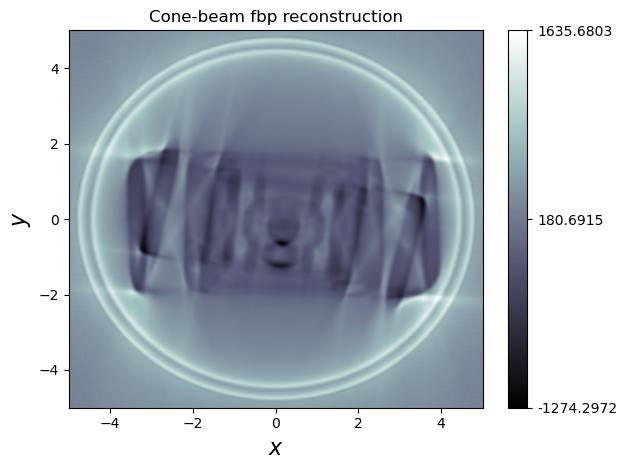

In [275]:
reco = fbp(proj_data)
reco.show(title="Cone-beam fbp reconstruction")

Creating sinogram from row 115 of 360 images...
  Loaded rcropIm01_mean.tif, angle=-179.99993 deg, projection shape: (304,)
  Loaded rcropIm61_mean.tif, angle=-120.00648 deg, projection shape: (304,)
  Loaded rcropIm121_mean.tif, angle=-60.01304 deg, projection shape: (304,)
Sinogram creation complete. Created 180 projections.


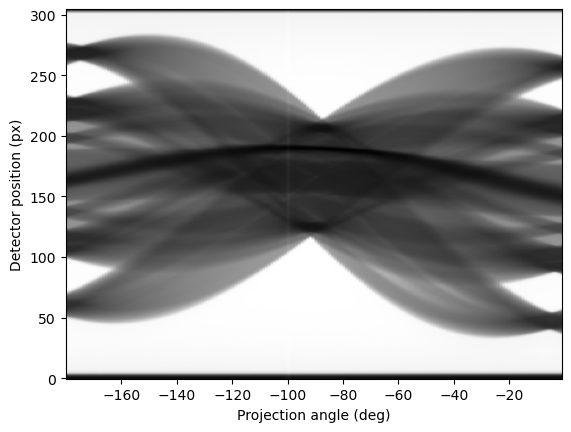

(304, 180)

In [276]:
# Reconstruction with just half rotation
sino = acq.create_sinogram(row=115, max_projections=180)
sino.plot()
sino._data.shape

In [393]:
reco_space = odl.uniform_discr(
    min_pt=[-5, -5], max_pt=[5, 5], shape=[256,256],
    dtype='float32')
angle_partition = odl.uniform_partition(-np.pi, 0, 180)
detector_partition = odl.uniform_partition(-10, 10, 304)
geometry = odl.tomo.FanBeamGeometry(angle_partition, detector_partition, src_radius=16.5, det_radius=17, src_to_det_init=(-0.3,-2.8), det_axis_init=(4,0),)
#src_shift_func=lambda angle: odl.tomo.flying_focal_spot(angle, apart=angle_partition, shifts=[(-0.2, 0.3), (-5, 0.2), (4,4)]))

ray_trafo = odl.tomo.RayTransform(reco_space, geometry)
fbp = odl.tomo.fbp_op(ray_trafo, filter_type='Hann', frequency_scaling=0.8)

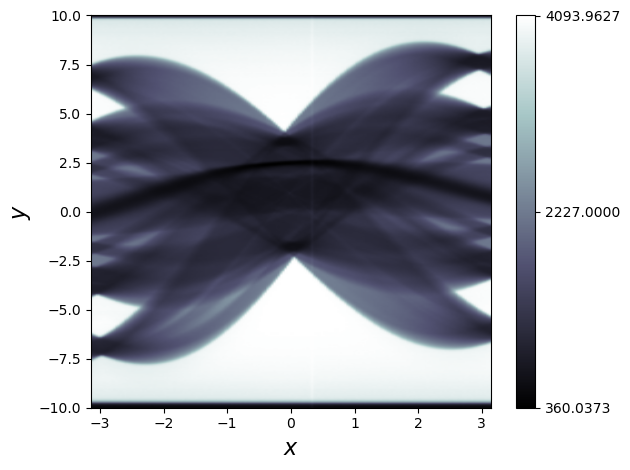

<Figure size 640x480 with 0 Axes>

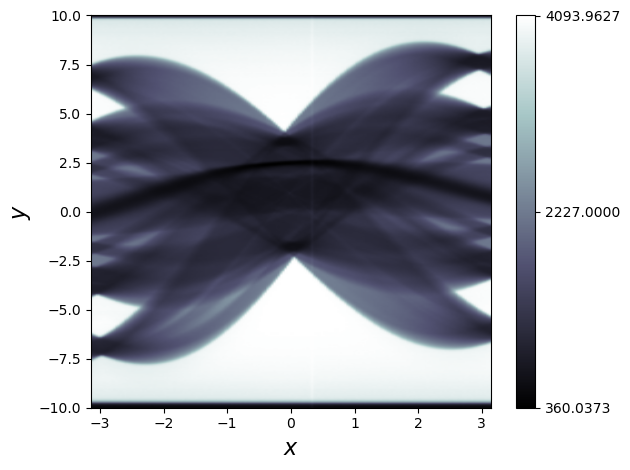

In [394]:
sino_space = odl.uniform_discr(
    min_pt=[-np.pi,-10], max_pt=[np.pi,10], shape=[180,304],
    dtype='float32')

proj_data = sino_space.element(np.flip(sino._data.T))
proj_data.show()

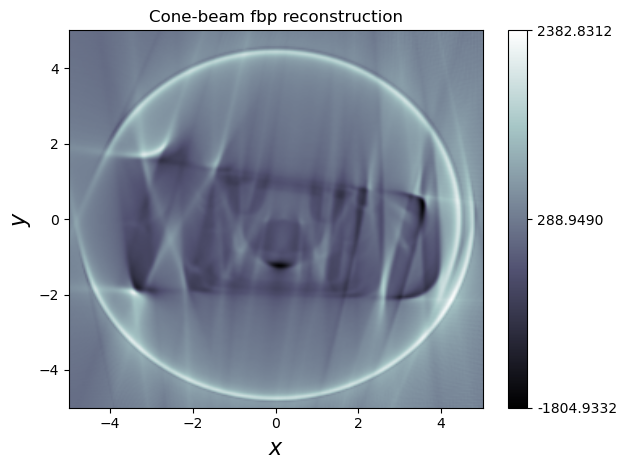

<Figure size 640x480 with 0 Axes>

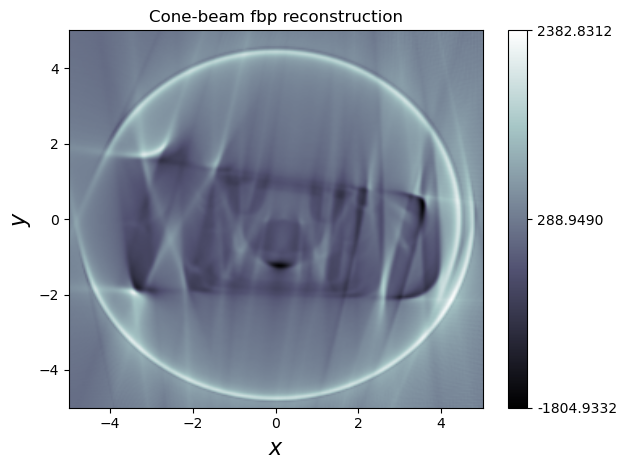

In [395]:
reco = fbp(proj_data)
reco.show(title="Cone-beam fbp reconstruction")

Creating sinogram from row 115 of 360 images...
  Loaded rcropIm01_mean.tif, angle=-179.99993 deg, projection shape: (304,)
  Loaded rcropIm61_mean.tif, angle=-120.00648 deg, projection shape: (304,)
  Loaded rcropIm121_mean.tif, angle=-60.01304 deg, projection shape: (304,)
  Loaded rcropIm181_mean.tif, angle=-0.01959 deg, projection shape: (304,)
  Loaded rcropIm241_mean.tif, angle=59.97385 deg, projection shape: (304,)
  Loaded rcropIm301_mean.tif, angle=119.9673 deg, projection shape: (304,)
Sinogram creation complete. Created 360 projections.


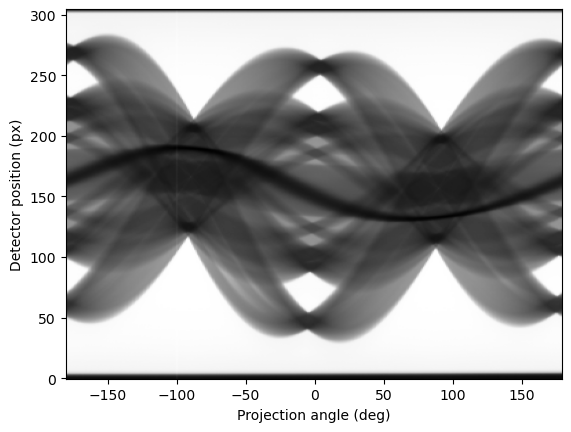

(304, 360)

In [389]:
sino2 = acq.create_sinogram(row=115)
sino2.plot()
sino2._data.shape

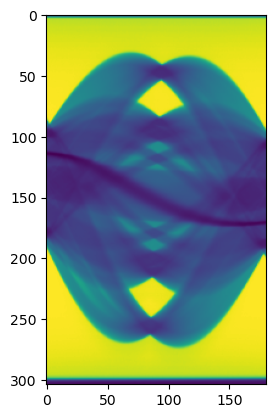

In [392]:
sino_cut = sino2._data[:, 90:271]
plt.imshow(sino_cut)

memoryview